<a href="https://colab.research.google.com/github/burningdust/ESAA/blob/main/YB_Session/ESAA_YB_0515_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%ED%9A%8C%EA%B7%802.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 규제 선형 회귀 모델/ 회귀 트리**
- 릿지 회귀모델 및 회귀 트리를 이용하여 전복의 나이를 예측해 보세요.

- 전복의 ‘성별’, ‘키’, ‘지름’, ‘높이’, ‘전체무게’, ‘몸통무게’, ‘내장무게’, ‘껍질무게’를 이용해 ‘껍질의 고리수’를 예측한 뒤, **예측된 ‘껍질의 고리수’에 1.5를 더하면 전복의 나이**가 됩니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 기본 모듈 불러오기
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore')

### 1) 데이터 불러오기 및 데이터 선택

In [28]:
# 데이터 로드
file_path = '/content/drive/MyDrive/이화여자대학교/ESAA/비대면 세션/data/'
data = pd.read_csv(file_path + "abalone.csv")

# 성별 M은 Male, F는 Female, I는 Infant 이므로 따로 열 만들기
for label in "MFI":
    data[label] = data["Sex"] == label
data.drop('Sex', axis=1, inplace=True)

# X,y 데이터 선택
y = data.Rings.values
data.drop('Rings', axis=1, inplace=True)

X = data.values.astype(float)

## 2) train/test 분리
: 테스트 셋과 데이터 셋을 7:3 비율로 분리하세요.

In [29]:
# 필요한 모듈 불러오기
from sklearn.model_selection import train_test_split

In [30]:
# train과 test set 분리 (train:test = 7:3 비율로)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

## 3) 릿지 모델을 이용한 모델링
: 릿지 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

 3-1) 릿지모델 생성, 교차검증, 평가에 필요한 모듈을 불러오세요.

In [31]:
#필요한 모듈 불러오기
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

3-2) 릿지 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요. 릿지 모델 생성 시  alpha는 0.3으로 설정합니다. (교차 검증 하지 않습니다.)

In [32]:
#릿지모델 생성 및 훈련
lr_ridge = Ridge(alpha=0.3)
lr_ridge.fit(X_train, y_train)

#예측값 구하기
y_pred = lr_ridge.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
y_pred_age = y_pred + 1.5

#MSE와 RMSE구하기
MSE = mean_squared_error(y_test, y_pred_age)
RMSE = np.sqrt(MSE)

print(f'MSE: {MSE:.4f}, RMSE: {RMSE:.4f}')

MSE: 7.0721, RMSE: 2.6593


3-3) 릿지 모델에서 회귀 계수 값을 구해 알 수 있는 점을 작성하시오. (각 컬럼의 정보는 data.colums 참고)

In [33]:
data.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'M', 'F', 'I'],
      dtype='object')

In [34]:
ridge_coef = pd.Series(lr_ridge.coef_, index=data.columns)
print('회귀 계수 값:\n', ridge_coef)

회귀 계수 값:
 Length             1.730623
Diameter           8.561149
Height             6.400273
Whole weight       8.006314
Shucked weight   -18.870049
Viscera weight    -8.934170
Shell weight      10.532604
M                  0.330514
F                  0.238986
I                 -0.569500
dtype: float64


양의 회귀계수 값을 가진 컬럼은 해당 값이 클수록 전복 나이도 커지는 양의 상관관계를 가짐을 나타내고, 음의 회귀계수 값을 가진 컬럼은 반대로 음의 상관관계를 가짐을 나타낸다. 그 값은 해당 값이 얼마나 증가해야 전복의 나이에 영향을 미치는지 크기를 나타낸다.

3-3) 교차검증을 이용하여 0, 0.1, 1, 10, 100 중  모델 성능이 가장 좋게 나오는 (rmse가 최소가 되는) alpha를 구하세요.

In [37]:
# 주어진 alpha
alphas=[0, 0.1, 1, 10, 100]

In [39]:
#alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
  ridge = Ridge(alpha=alpha)

  #cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
  neg_mse_scores = cross_val_score(ridge, X_train, y_train,
                                   scoring='neg_mean_squared_error', cv=5)
  avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
  print('alpha {0}일 때 5 folds의 평균 RMSE: {1:.3f}'.format(alpha, avg_rmse))


alpha 0일 때 5 folds의 평균 RMSE: 2.192
alpha 0.1일 때 5 folds의 평균 RMSE: 2.189
alpha 1일 때 5 folds의 평균 RMSE: 2.192
alpha 10일 때 5 folds의 평균 RMSE: 2.336
alpha 100일 때 5 folds의 평균 RMSE: 2.604


## 4) XGBRegressor을 이용한 모델링
: XGBRegressor 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

4-1) XGBRegressor 훈련, 평가에 필요한 모듈을 불러오세요.

In [40]:
# 필요한 모듈 임포트
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

4-2) XGBregressor 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요.

In [41]:
#모델 생성 및 훈련
lr_xgb = XGBRegressor()
lr_xgb.fit(X_train, y_train)

#예측값 구하기
y_pred = lr_xgb.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
y_pred_age = y_pred + 1.5

#MSE와 RMSE 구하기
MSE = mean_squared_error(y_test, y_pred_age)
RMSE = np.sqrt(MSE)

print(f'MSE: {MSE}\nRMSE: {RMSE}')

MSE: 7.546839237213135
RMSE: 2.7471511129191883


4-3) 생성한 모델의 피처 중요도를 시각화해보세요.

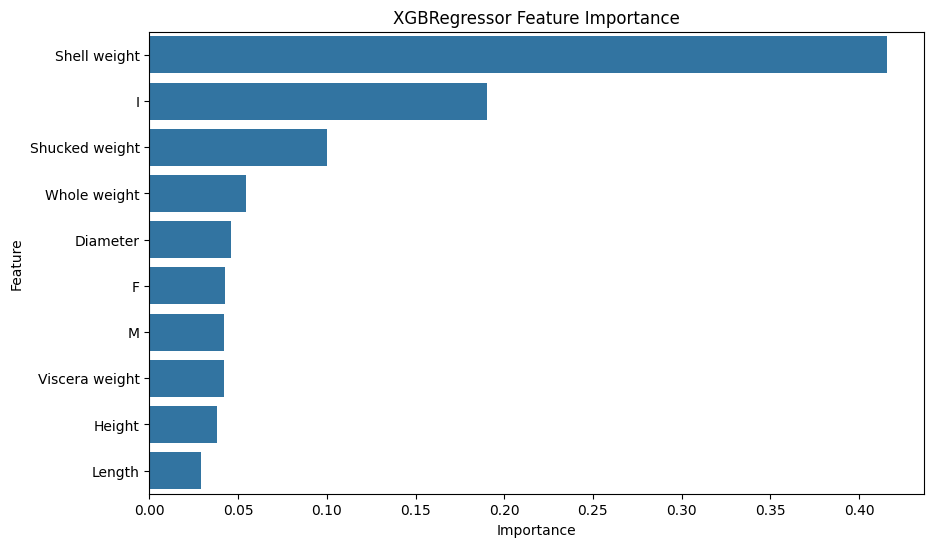

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 피처 중요도
feature_importance = lr_xgb.feature_importances_
feature_names = data.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBRegressor Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# **2. 로지스틱 회귀분석**
load_wine() 함수를 이용하여 와인 데이터를 다항분류하는 로지스틱 회귀모델을 생성하세요.

In [43]:
# 필요한 모듈 불러오기
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

## 1) 데이터 불러오기 및 변수 선택

In [44]:
wine = load_wine()

wine_x = wine.data # x변수
wine_y = wine.target # y변수

## 2) train/test 셋 분리

In [46]:
x_train, x_test, y_train, y_test = train_test_split(wine_x, wine_y, test_size=0.3, random_state=123)

print(x_train.shape)
print(y_train.shape)

(124, 13)
(124,)


## 3) 로지스틱 회귀모델을 이용한 모델링

3-1) 로지스틱 회귀모델을 생성하여 훈련하세요.

In [47]:
lr_log = LogisticRegression()
lr_log.fit(x_train, y_train)

LogisticRegression()

3-2) 회귀 모델의 기울기와 절편을 구하세요.

In [48]:
#기울기
print(np.round(lr_log.coef_, 4))

[[-1.9980e-01  3.6550e-01  1.4950e-01 -1.8800e-01 -2.2800e-02  1.9550e-01
   4.6670e-01 -1.6700e-02  8.2400e-02  6.7500e-02 -1.9300e-02  2.9490e-01
   7.4000e-03]
 [ 5.9650e-01 -7.8870e-01 -1.2620e-01  2.1230e-01 -1.1400e-02  3.1580e-01
   3.5510e-01  3.3500e-02  2.7900e-01 -1.1720e+00  2.6120e-01  4.6470e-01
  -8.3000e-03]
 [-3.9670e-01  4.2320e-01 -2.3300e-02 -2.4200e-02  3.4200e-02 -5.1120e-01
  -8.2190e-01 -1.6800e-02 -3.6140e-01  1.1045e+00 -2.4190e-01 -7.5960e-01
   9.0000e-04]]


In [49]:
#절편
print(np.round(lr_log.intercept_, 4))

[-0.0418  0.0955 -0.0537]


3-3) 모델의 정확도를 구하세요.

In [50]:
#모델의 예측값 구하기
y_pred = lr_log.predict(x_test)

#모델의 정확도 구하기
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f'{accuracy:.4f}')

0.9630
